1. Detect the missing and outlier data.

In [19]:
#import xlsx data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Train_data=pd.read_excel("Dataset/TrainingData.xlsx",header=None,names=['A','B','C','D','E'])
Test_data=pd.read_excel("Dataset/TestData.xlsx",header=None,names=['A','B','C','D'])

for col in Train_data.columns:
    Train_data[col] = pd.to_numeric(Train_data[col], errors='coerce')

print(Train_data.shape)
print(Train_data.columns)

#check missing
missing_train=Train_data.isna()
missing_train_n=missing_train.sum()
print(missing_train_n)
missing_test=Test_data.isna()
missing_test_n=missing_test.sum()
print(missing_test_n)
# X_train=Train_data[[0,1,2,3]].to_numpy
# y_train=Train_data[4].to_numpy

Train_data.fillna(Train_data.mean(), inplace=True)
Test_data.fillna(Test_data.mean(), inplace=True)

print("Check missing & type:")
print(Train_data.dtypes)
print(Train_data.isna().sum())

(120, 5)
Index(['A', 'B', 'C', 'D', 'E'], dtype='object')
A    2
B    0
C    0
D    1
E    0
dtype: int64
A    0
B    0
C    0
D    0
dtype: int64
Check missing & type:
A    float64
B    float64
C    float64
D    float64
E      int64
dtype: object
A    0
B    0
C    0
D    0
E    0
dtype: int64


In [20]:
mu_train=Train_data.mean()
mu_test=Test_data.mean()
sigma_train=Train_data.std()
sigma_test=Test_data.std()

def Zscore(data,mu,sigma):
    z=(data-mu)/sigma
    outlier=np.abs(z)>3
    return outlier

outlier_train=Zscore(Train_data,mu_train,sigma_train)
outlier_test=Zscore(Test_data,mu_test,sigma_test)
outlier_train_n=outlier_train.sum()
outlier_test_n=outlier_test.sum()
print(outlier_train_n)
print(outlier_test_n)
Train_clean=Train_data.mask(outlier_train,Train_data.median(),axis=1)
Test_clean=Test_data
print("Check Clean Result:")
print(Zscore(Train_clean,Train_clean.mean(),Train_clean.std()).sum())


A    1
B    1
C    1
D    1
E    0
dtype: int64
A    0
B    0
C    0
D    0
dtype: int64
Check Clean Result:
A    0
B    0
C    0
D    0
E    0
dtype: int64


A    1
B    2
C    1
D    1
E    0
dtype: int64
A    0
B    0
C    0
D    0
dtype: int64


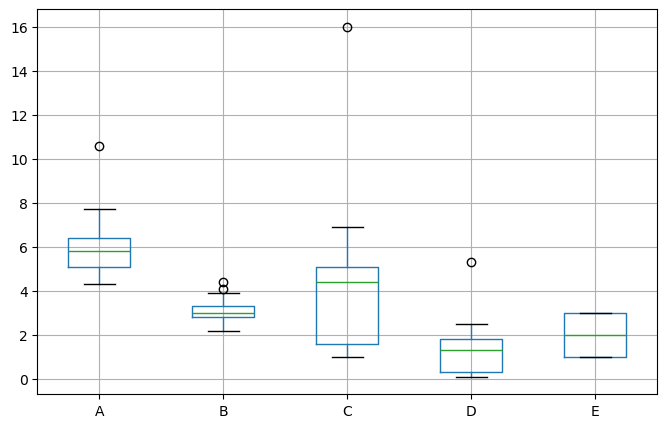

Check Clean Result (Train):
A    0
B    0
C    0
D    0
E    0
dtype: int64


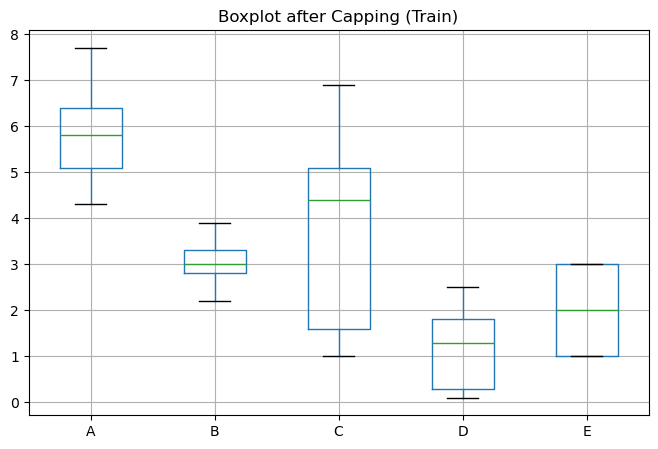

In [21]:
# use IQR and box plot to detect outliers
def IQR(data):
    Q1=data.quantile(.25)
    Q3=data.quantile(.75)
    IQR=Q3-Q1
    outlier=(data<(Q1-1.5*IQR))|(data>(Q3+1.5*IQR))
    return outlier

outlier_train_IQR=IQR(Train_data)
outlier_test_IQR=IQR(Test_data)
outlier_train_n=outlier_train_IQR.sum()
outlier_test_n=outlier_test_IQR.sum()

print(outlier_train_n)
print(outlier_test_n)

plt.figure(figsize=(8,5))
Train_data.boxplot(column=['A','B','C','D','E'])
plt.savefig("/Users/zimin/Develop/VScode_Project/EE6407_GA_ML/Assignments/Report/Images/Assignment_1/Boxplot_Train.png")
plt.show()

# Train_clean=Train_data.mask(outlier_train_IQR,Train_data.median(),axis=1)
# Test_clean=Test_data
# print("Check Clean Result:")
# print(IQR(Train_clean).sum())

# plt.figure(figsize=(8,5))
# Train_clean.boxplot(column=['A','B','C','D','E'])
# plt.show()

p05 = Train_data.quantile(0.05)
p95 = Train_data.quantile(0.95)

Q1 = Train_data.quantile(0.25)
Q3 = Train_data.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

Train_capped = Train_data.copy()
for col in Train_data.columns:
    Train_capped[col] = np.where(
    Train_data[col] < lower[col], p05[col],
    np.where(
        Train_data[col] > upper[col], p95[col], 
        Train_data[col])
    )
print("Check Clean Result (Train):")
print(((Train_capped < lower) | (Train_capped > upper)).sum())

plt.figure(figsize=(8,5))
Train_capped.boxplot(column=['A','B','C','D','E'])
plt.title("Boxplot after Capping (Train)")
plt.savefig("/Users/zimin/Develop/VScode_Project/EE6407_GA_ML/Assignments/Report/Images/Assignment_1/Boxplot_Train_Capped.png")
plt.show()

2. Trans to train and test numpy set

In [22]:
X_train=Train_clean[['A','B','C','D']].to_numpy()
y_train=Train_clean['E'].to_numpy()
X_test=Test_clean.to_numpy()

3. Set up Naive Bayes Classifier

In [23]:
class GNB_Classifier:
    def __init__(self):
        pass

    def fit(self,X,y):
        self.classes=np.unique(y)
        self.means=[]
        self.vars=[]
        self.priors=[]
        for w in self.classes:
            X_w=X[y==w]
            prior_w=X_w.shape[0]/X.shape[0]
            mean_w=np.mean(X_w,axis=0)
            # cov_w=np.cov(X_w,rowvar=False)+1e-6*np.eye(X.shape[1]) 
            var_w = np.var(X_w, axis=0)
            self.priors.append(prior_w)
            self.means.append(mean_w)
            # self.vars.append(cov_w)
            self.vars.append(var_w)

        self.priors = np.array(self.priors)
        self.means = np.array(self.means)
        self.vars = np.array(self.vars)


    def ConditionPwithGaussian(self,x,mean,var):
        eps = 1e-6 
        coeff = 1.0 / np.sqrt(2 * np.pi * var + eps)
        exponent = - (x - mean) ** 2 / (2 * var + eps)
        return coeff * np.exp(exponent)

    def predict(self, X):
        X = np.array(X)
        y_pred = []

        for x in X:
            posteriors = []
            for i, c in enumerate(self.classes):
                prior_log = np.log(self.priors[i])
                likelihood_log = np.sum(np.log(self.ConditionPwithGaussian(x, self.means[i], self.vars[i])))
                posteriors.append(prior_log + likelihood_log)
            y_pred.append(self.classes[np.argmax(posteriors)])

        return np.array(y_pred)

    def evaluate(self, X, y):
        y = np.array(y)
        y_pred = self.predict(X)
        accuracy = np.mean(y_pred == y)
        return accuracy



4. Prediction

In [25]:
classifier=GNB_Classifier()
classifier.fit(X_train,y_train)
y_predict=classifier.predict(X_test)
score=classifier.evaluate(X_train,y_train)
print("Accuracy for training set:",score)
print("Predicted labels for test set:")
print(y_predict)


results = {
    "Metric": ["Training Accuracy", "Predicted Labels"],
    "Value": [f"{score:.6f}", str(y_predict)]
}
df = pd.DataFrame(results)  

with open("/Users/zimin/Develop/VScode_Project/EE6407_GA_ML/Assignments/Report/Images/Assignment_1/results_table.tex", "w") as f:
    f.write("\\begin{table}[H]\n")
    f.write("\\centering\n")
    f.write("\\caption{Results of Gaussian Naive Bayes Classifier}\n")
    f.write(df.to_latex(index=False, caption=None))
    f.write("\\end{table}\n")



Accuracy for training set: 0.9583333333333334
Predicted labels for test set:
[1 1 1 1 1 1 1 1 1 1 3 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3]
